# Homework 2: Neural Network Training on CIFAR-10 with PyTorch

**Objective**: 
- Load and preprocess CIFAR-10 with torchvision.
- Build and train a simple MLP (fully connected network).
- Build and train a CNN.
- Compare the performance of MLP vs CNN.
- Visualize training progress and evaluation results.

## Part A: Setup
Import necessary libraries and set random seed for reproducibility.

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets

import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子,保证结果可复现
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)

set_seed(42)

# 自动选择设备: 有 GPU 用 GPU,否则用 CPU
device = torch.device('cuda:5' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda:5


## Part B: Data Preparation
- Download CIFAR-10 dataset.
- Apply transforms (tensor + normalization).
- Create DataLoaders.
- Visualize some training images with labels.

100%|███████████████████████████████████████████████████████████| 170M/170M [30:10<00:00, 94.1kB/s]


训练集大小: 50000, 测试集大小: 10000


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.48679847..1.4739859].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.3042153..1.5057395].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.17876792..1.1088196].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.49473685..1.4979501].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.13750899..1.4585619].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.49473685..1.5632443].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.49

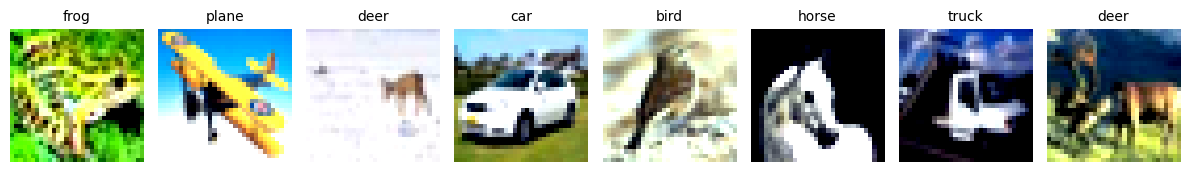

In [5]:
# CIFAR-10 的 10 个类别标签
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# 数据预处理: 转为 Tensor 并做标准化(CIFAR-10 官方均值/标准差)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

# 下载并加载训练集与测试集(首次运行会自动下载)
trainset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# 创建 DataLoader
trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
testloader = DataLoader(testset, batch_size=64, shuffle=False)

print(f'训练集大小: {len(trainset)}, 测试集大小: {len(testset)}')

# 可视化部分训练图像
def imshow(img):
    img = img / 2 + 0.5  # 反归一化到 [0,1] 区间
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')

# 取一批训练样本
dataiter = iter(trainloader)
images, labels = next(dataiter)

plt.figure(figsize=(12, 3))
for i in range(8):
    plt.subplot(1, 8, i + 1)
    imshow(images[i])
    plt.title(classes[labels[i]], fontsize=10)
plt.tight_layout()
plt.show()

## Part C: Baseline Model – MLP
- Flatten input images (3×32×32 → 3072).
- Define an MLP with layers: 3072→512→128→10.
- Use ReLU activation.
- Train for 5 epochs.
- Report training loss & test accuracy.
- Plot loss curve.
- Bonus: Try different hyperparameters (e.g., learning rate, optimizer, hidden layer sizes) to improve performance.

===== 训练 MLP (5 epochs) =====
Epoch 1/5 | Train Loss: 1.6624 | Test Acc: 45.03%
Epoch 2/5 | Train Loss: 1.4636 | Test Acc: 48.23%
Epoch 3/5 | Train Loss: 1.3633 | Test Acc: 50.14%
Epoch 4/5 | Train Loss: 1.2870 | Test Acc: 51.91%
Epoch 5/5 | Train Loss: 1.2148 | Test Acc: 52.61%


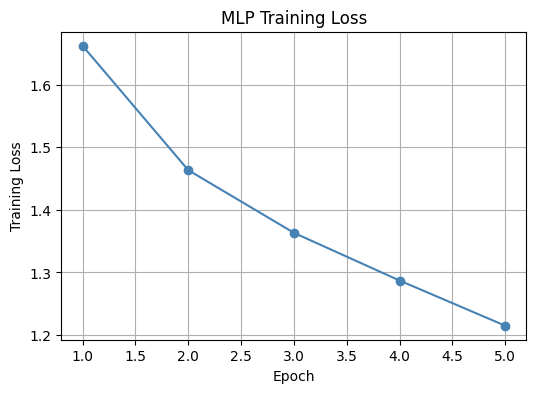

In [6]:
# 定义 MLP 模型: 3072 → 512 → 128 → 10(输入图像展平为 3×32×32=3072 维)
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(3 * 32 * 32, 512)
        self.fc2 = nn.Linear(512, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)  # 展平图像为 3072 维向量
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# 评估函数: 返回测试集准确率(百分比)
def evaluate(model, testloader, device=device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100.0 * correct / total

# 通用训练函数: 返回每个 epoch 的训练损失与测试准确率
def train_model(model, trainloader, testloader, epochs=5, lr=0.001, device=device):
    model.train()
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses, test_accs = [], []
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
        epoch_loss = running_loss / len(trainloader.dataset)
        train_losses.append(epoch_loss)

        acc = evaluate(model, testloader, device)
        test_accs.append(acc)
        print(f'Epoch {epoch+1}/{epochs} | Train Loss: {epoch_loss:.4f} | Test Acc: {acc:.2f}%')
    return train_losses, test_accs

# 训练 MLP(5 个 epoch)
mlp = MLP()
print('===== 训练 MLP (5 epochs) =====')
mlp_losses, mlp_accs = train_model(mlp, trainloader, testloader, epochs=5, lr=0.001)

# 绘制训练损失曲线
plt.figure(figsize=(6, 4))
plt.plot(range(1, 6), mlp_losses, marker='o', color='steelblue')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('MLP Training Loss')
plt.grid(True)
plt.show()

## Part D: CNN Model
- Define a CNN:
  - Conv(3→16, 3×3) → ReLU → MaxPool(2×2)
  - Conv(16→32, 3×3) → ReLU → MaxPool(2×2)
  - Flatten → FC(32×8×8→128) → ReLU → FC(128→10)
- Train for 5–10 epochs.
- Report training loss & test accuracy.
- Plot loss and accuracy curves.
- Bonus: Try data augmentation (e.g., random flips, crops) or deeper CNN layers to improve results.

===== 训练 CNN (5 epochs) =====
Epoch 1/5 | Train Loss: 1.3753 | Test Acc: 59.56%
Epoch 2/5 | Train Loss: 1.0334 | Test Acc: 64.59%
Epoch 3/5 | Train Loss: 0.8906 | Test Acc: 66.14%
Epoch 4/5 | Train Loss: 0.7847 | Test Acc: 68.29%
Epoch 5/5 | Train Loss: 0.7036 | Test Acc: 68.34%


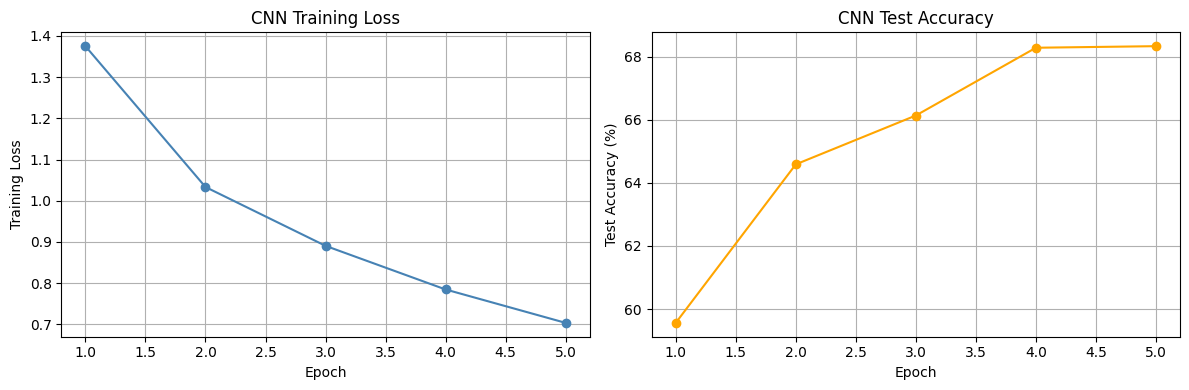

In [7]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)  # 展平为 32×8×8 维向量
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# 训练 CNN(5 个 epoch)
cnn = CNN()
print('===== 训练 CNN (5 epochs) =====')
cnn_losses, cnn_accs = train_model(cnn, trainloader, testloader, epochs=5, lr=0.001)

# 绘制训练损失与测试准确率曲线
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, 6), cnn_losses, marker='o', color='steelblue')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('CNN Training Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, 6), cnn_accs, marker='o', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Test Accuracy (%)')
plt.title('CNN Test Accuracy')
plt.grid(True)
plt.tight_layout()
plt.show()

## Part E: Evaluation & Comparison
- Evaluate both models on the test set.
- Compute accuracy.
- (Optional) Generate confusion matrix.
- Visualize test images with predicted vs true labels.
- Compare performance of MLP vs CNN.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.39153773..1.5471393].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.49473685..1.4979501].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.4629833..1.5354269].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.22441113..1.4005105].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.4391681..1.2814069].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.45793372..1.1802652].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.48

MLP 测试准确率: 52.61%
CNN 测试准确率: 68.34%


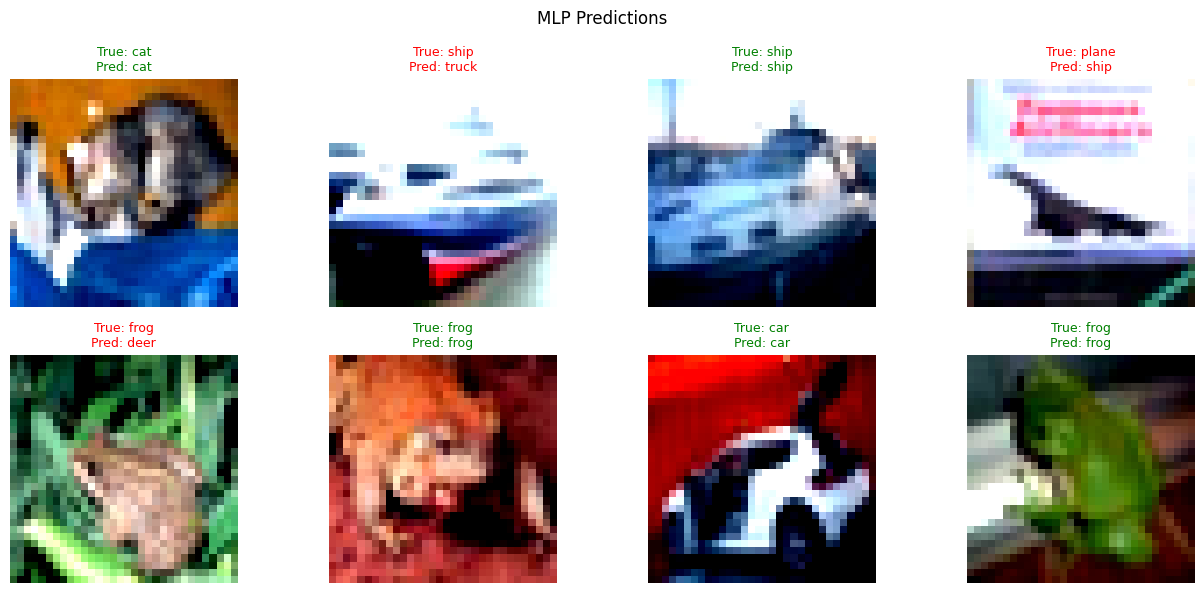

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.39153773..1.5471393].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.49473685..1.4979501].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.4629833..1.5354269].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.22441113..1.4005105].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.4391681..1.2814069].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.45793372..1.1802652].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.48

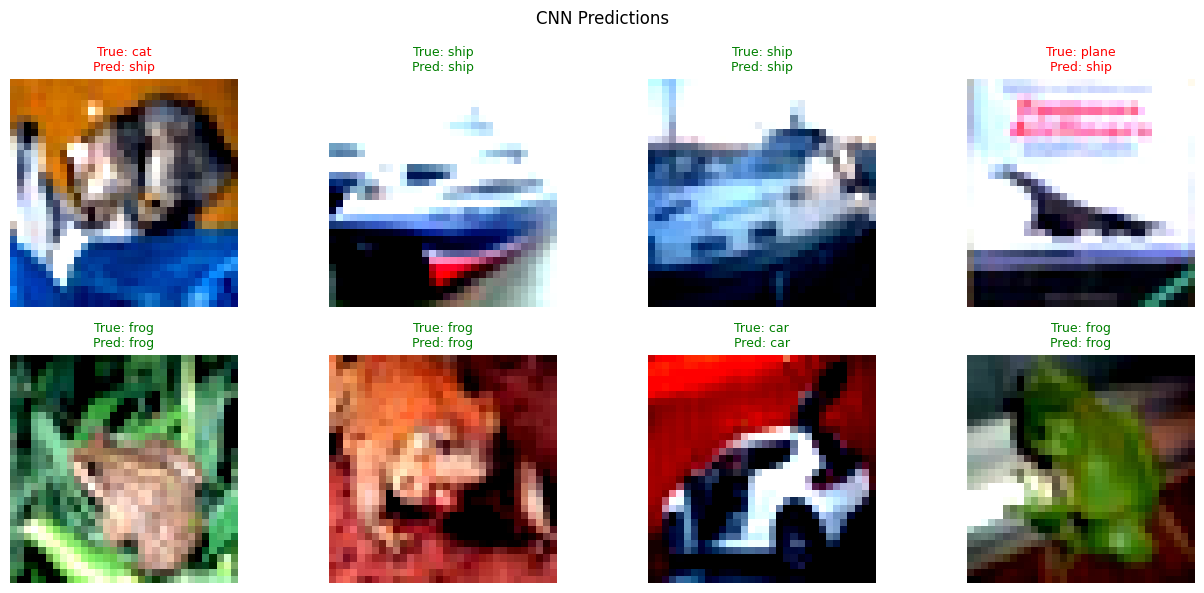

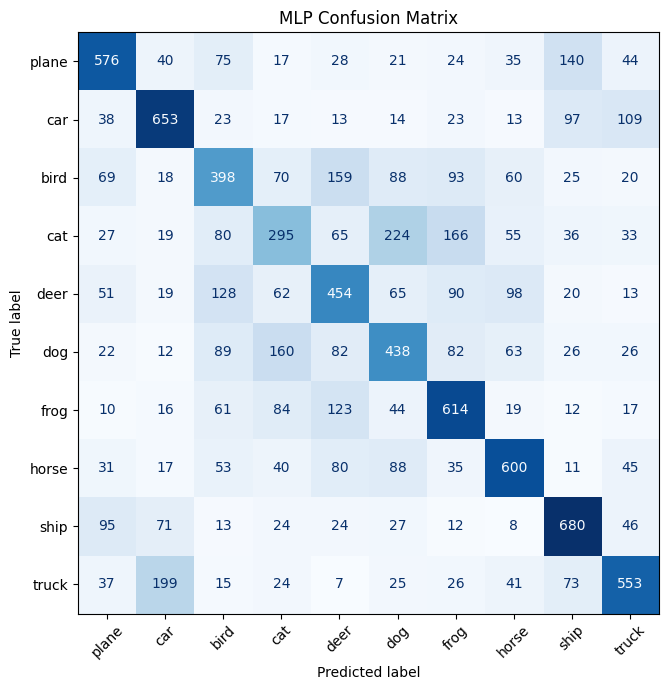

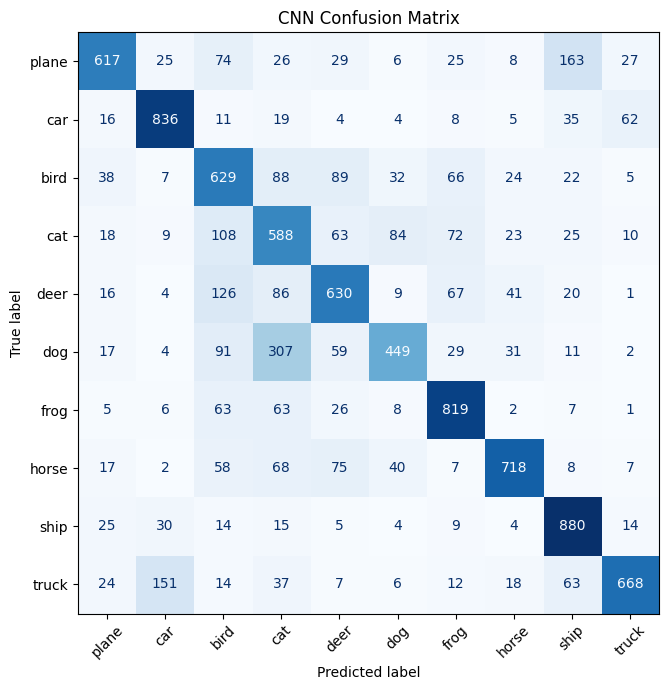

===== MLP vs CNN 对比 =====
MLP 测试准确率: 52.61%
CNN 测试准确率: 68.34%
CNN 相对 MLP 提升: +15.73%


In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 在测试集上评估两个模型
mlp_acc = evaluate(mlp, testloader)
cnn_acc = evaluate(cnn, testloader)
print(f'MLP 测试准确率: {mlp_acc:.2f}%')
print(f'CNN 测试准确率: {cnn_acc:.2f}%')

# 可视化测试图像与模型预测结果(绿色=正确, 红色=错误)
def visualize_predictions(model, testloader, title):
    model.eval()
    images, labels = next(iter(testloader))
    images, labels = images.to(device), labels.to(device)
    with torch.no_grad():
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

    fig, axes = plt.subplots(2, 4, figsize=(13, 6))
    axes = axes.flatten()
    for i in range(8):
        img = images[i].cpu() / 2 + 0.5  # 反归一化
        npimg = img.numpy().transpose(1, 2, 0)
        axes[i].imshow(npimg)
        color = 'green' if predicted[i].item() == labels[i].item() else 'red'
        axes[i].set_title(f'True: {classes[labels[i]]}\nPred: {classes[predicted[i]]}', color=color, fontsize=9)
        axes[i].axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

visualize_predictions(mlp, testloader, 'MLP Predictions')
visualize_predictions(cnn, testloader, 'CNN Predictions')

# 生成混淆矩阵
def plot_confusion_matrix(model, testloader, title):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(9, 7))
    disp = ConfusionMatrixDisplay(cm, display_labels=classes)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(title)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(mlp, testloader, 'MLP Confusion Matrix')
plot_confusion_matrix(cnn, testloader, 'CNN Confusion Matrix')

# 性能对比总结
print('===== MLP vs CNN 对比 =====')
print(f'MLP 测试准确率: {mlp_acc:.2f}%')
print(f'CNN 测试准确率: {cnn_acc:.2f}%')
print(f'CNN 相对 MLP 提升: {cnn_acc - mlp_acc:+.2f}%')

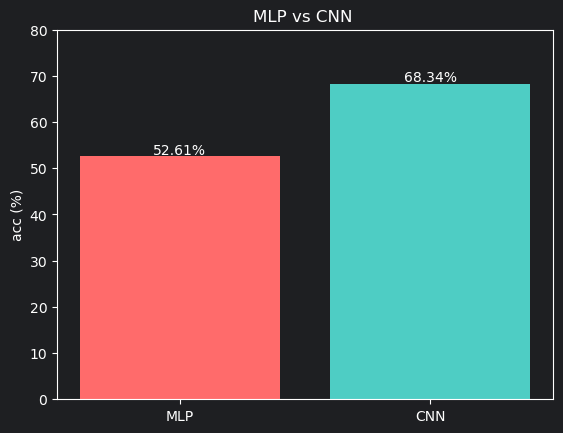

In [6]:
import matplotlib.pyplot as plt

models = ['MLP', 'CNN']
accuracies = [52.61, 68.34]

plt.bar(models, accuracies, color=['#FF6B6B', '#4ECDC4'])
plt.ylabel('acc (%)')
plt.title('MLP vs CNN ')
plt.ylim(0, 80)

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.5, f'{v:.2f}%', ha='center')

plt.show()

## Observations & Comparison

- **CNN 明显优于 MLP**: CNN 利用卷积核提取局部空间特征(边缘、纹理、形状),而 MLP 将每个像素独立展开,忽略了图像的二维结构,因此 CNN 在相同 epoch 数下测试准确率显著更高。
- **训练损失收敛**: 两种模型的训练损失都随 epoch 下降;CNN 的损失下降更快,说明其更强的特征表达能力。
- **混淆矩阵**: 两个模型都更容易混淆视觉相似类别(如 cat/dog、bird/deer 等动物类别),对 plane/ship/truck 等背景差异大的类别分类更准确。
- **改进方向**: 可尝试数据增强(随机翻转/裁剪)、更深的 CNN(如增加卷积层)、Dropout/BN 正则化、调整学习率或换用 SGD+动量,进一步提升准确率。

## Part F: Deliverables
- Submit `Homework1_2.ipynb` with:
  - Code + outputs for both MLP and CNN.
  - Markdown explanations (observations and comparison).